# Exploratory Data Analysis (EDA) — Bank Customer Churn

**Goal:** Build a clean, EDA that:
- Loads the raw dataset (`data/raw/churn.csv`)
- Summarizes structure (shape, dtypes, missing, duplicates)
- Visualizes *all* numeric distributions vs target in **one** figure
- Visualizes *all* numeric boxplots vs target in **one** figure
- Visualizes *all* categorical churn rates in **one** figure
- Creates a correlation heatmap
- Saves all visuals to `reports/eda/` and shows inline previews here

**Target column:** `Exited` (1 = churned, 0 = retained)

> This notebook only **explores**. Splits/feature engineering/modeling happen in `.py` files (pipeline-safe).


In [4]:
#=============================================
# 01. Imports & configurations
#=============================================
import os
import json
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
main=os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(main)
from commons import ensure_directory

# Robust import fpr local utils
from src.utils.plot_utils import(
    plot_numeric_distribution,
    plot_boxplots,
    plot_categorical_bars,
    plot_correlation_heatmap
    )

# Data Loader
from src.utils.file_utils import load_csv as load_raw_csv, save_json
from IPython.display import Image, display

# Noebook Display Options
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4.5)

RAW_PATH = "../data/raw/churn.csv"
REPORTS_EDA_DIRECTORY = "../reports/eda/"

ensure_directory(REPORTS_EDA_DIRECTORY)

print("Imports ok. Outputs will be saved to: ", REPORTS_EDA_DIRECTORY)    

Imports ok. Outputs will be saved to:  ../reports/eda/


In [5]:
#=============================================
# 02. Load Dataset
#=============================================


if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(f"Dataset not found ad: {RAW_PATH}")

data = load_raw_csv(RAW_PATH)
print("Data loaded: ", RAW_PATH)

print("Shape: ", data.shape)
display(data.head(3))
    

Data loaded:  ../data/raw/churn.csv
Shape:  (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [6]:
#=============================================
# 03. Data Description
#=============================================

print("columns: ", list(data.columns))
print("\nDataTypes:")
display(data.dtypes.to_frame("dtype"))

print("\nMissing Value % per column:")
missing_percentage = data.isna().mean().sort_values(ascending=False)
display(missing_percentage[missing_percentage > 0])

duplicate_count = data.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count} of ( {len(data)} )")

columns:  ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

DataTypes:


,dtype
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64



Missing Value % per column:


Series([], dtype: float64)


Duplicate rows: 0 of ( 10000 )


Target Class Ratio:


,ratio
Exited,
0,0.7963
1,0.2037


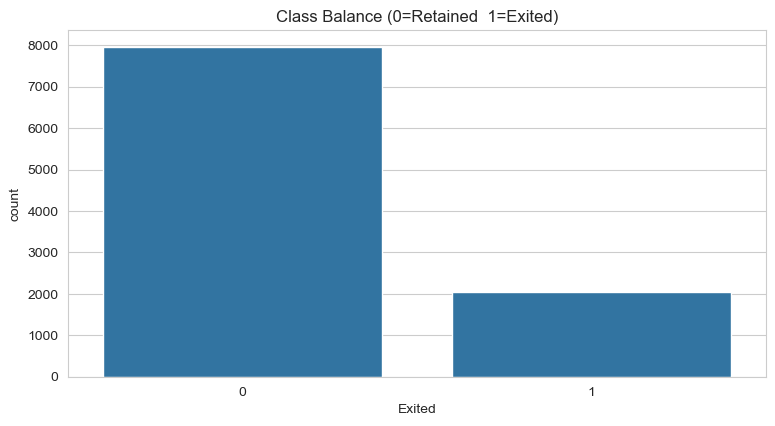

Saved:  ../reports/eda/target_distribution.png


In [7]:
#=============================================
# 04. Target Distribution
#=============================================

TARGET_COLUMN = "Exited"
if TARGET_COLUMN not in data.columns:
    raise KeyError(f"Target_column ({TARGET_COLUMN}) Not found in dataframe")

print("Target Class Ratio:")
display(data[TARGET_COLUMN].value_counts(normalize=True).rename("ratio").to_frame())

figure, axes = plt.subplots()
sns.countplot(data=data, x=TARGET_COLUMN, ax=axes)
axes.set_title("Class Balance (0=Retained  1=Exited)")
figure.savefig(os.path.join(REPORTS_EDA_DIRECTORY, "target_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Saved: ", os.path.join(REPORTS_EDA_DIRECTORY, "target_distribution.png"))



In [8]:
#=============================================
# 05. Column Groups
#=============================================
numeric_columns = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_columns = [column for column in numeric_columns if column != TARGET_COLUMN]

categorical_columns = [column for column in data.columns if column not in numeric_columns + [TARGET_COLUMN]]
print("numeric_columns: ", numeric_columns)
print("categorical_columns: ", categorical_columns)




numeric_columns:  ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_columns:  ['Surname', 'Geography', 'Gender']


Figure Saved: ../reports\eda\numeric_distribution.png


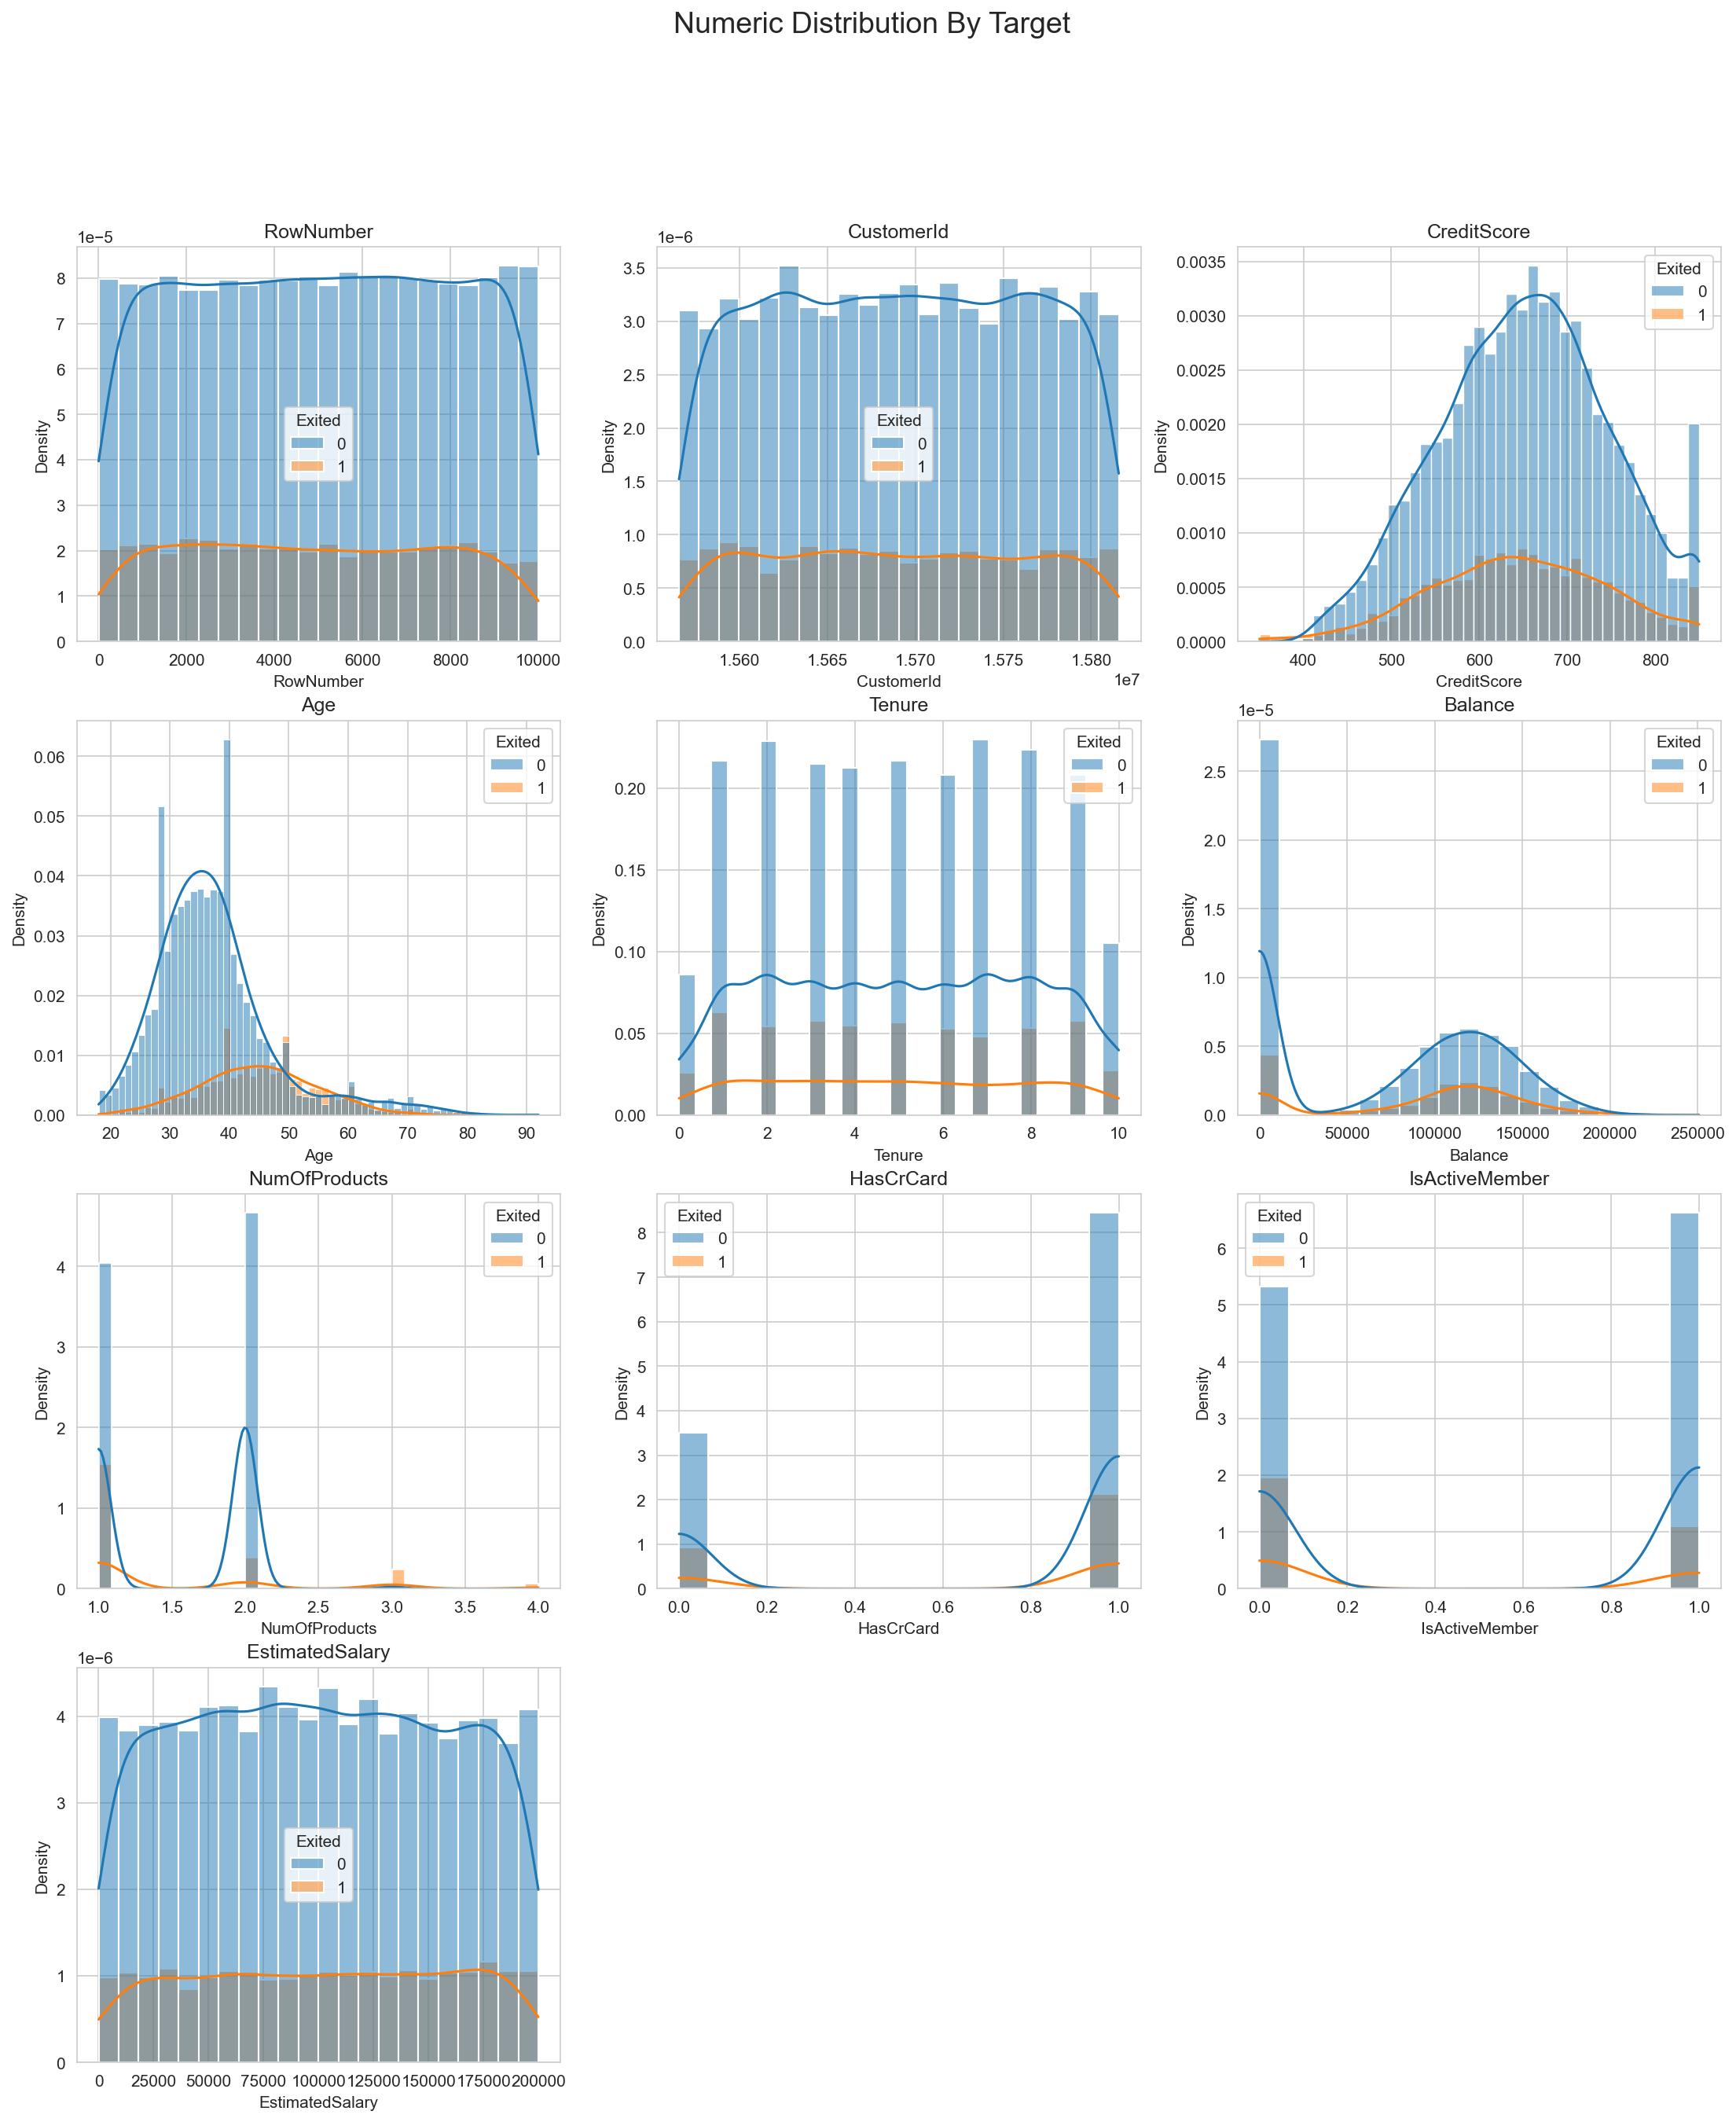

In [9]:
#=============================================
# 06. Numeric Distributions
#=============================================
plot_numeric_distribution(data, numeric_columns, target_column=TARGET_COLUMN)

#Inline Preview of the saved image
display(Image(filename=os.path.join(REPORTS_EDA_DIRECTORY, "numeric_distribution.png")))


Figure Saved: ../reports\eda\numeric_boxplot.png


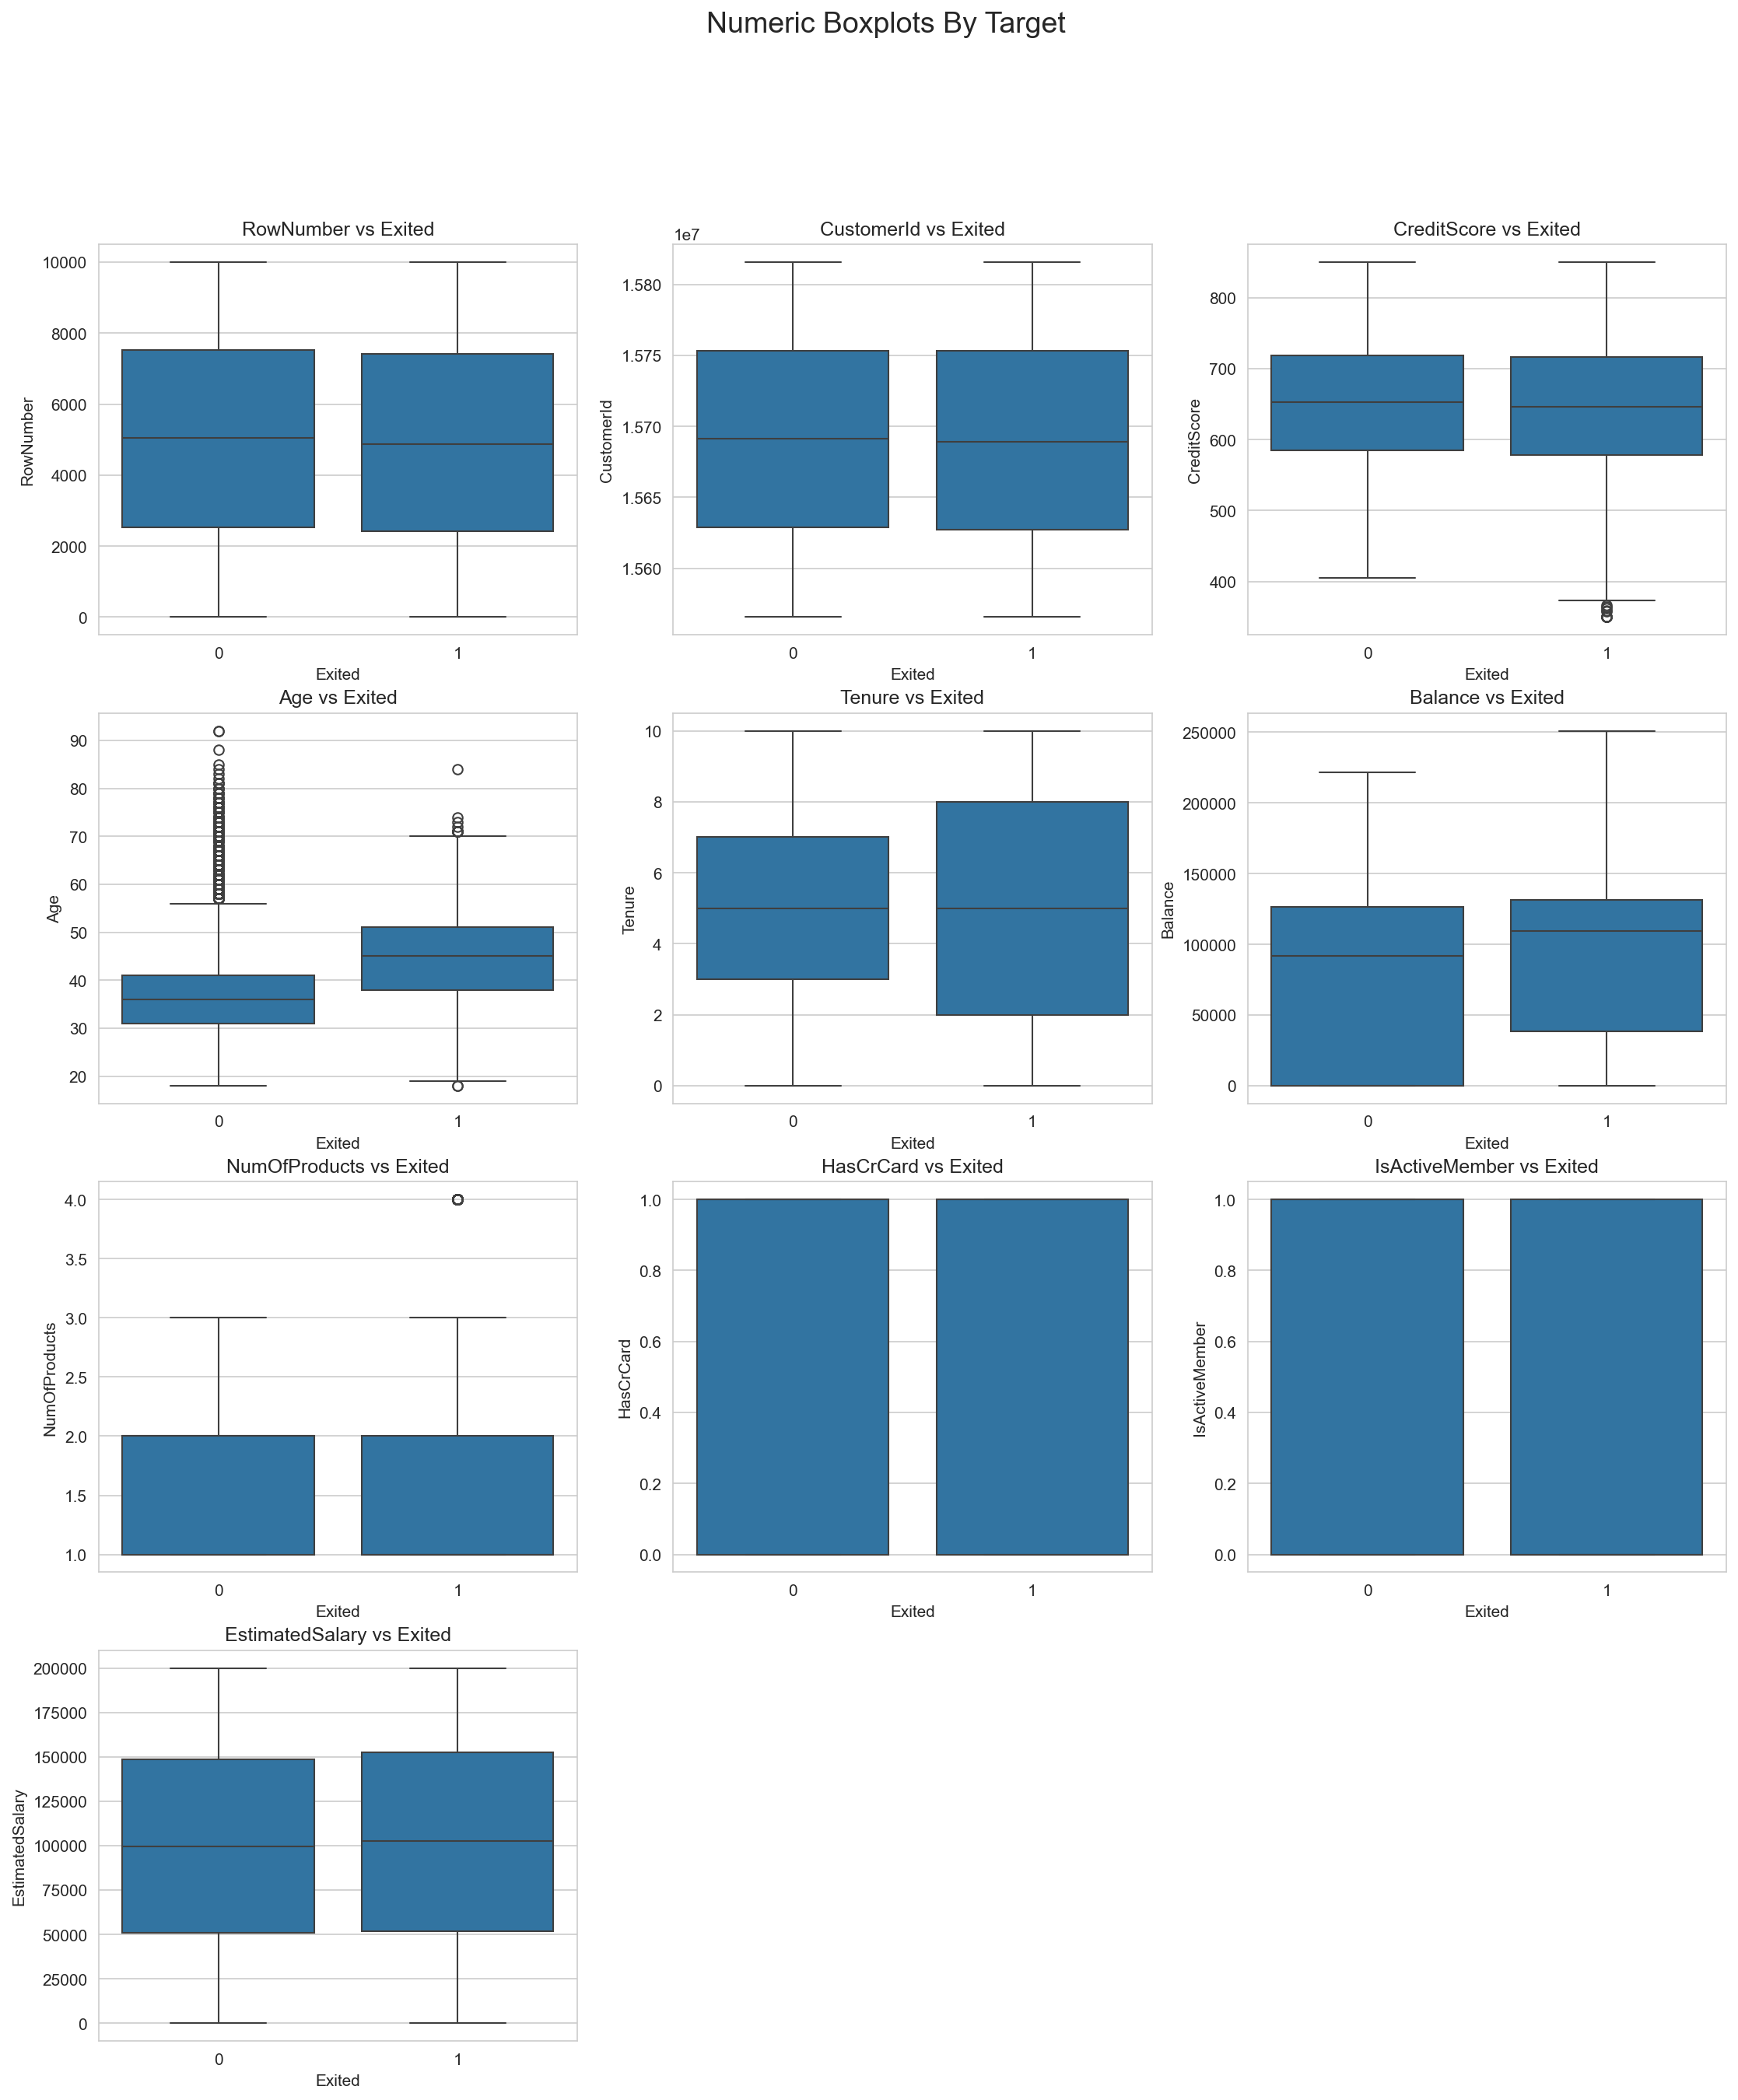

In [10]:
#=============================================
# 07. Numeric Boxplots vs Target
#=============================================
plot_boxplots(data, numeric_columns, target_column=TARGET_COLUMN)

#Inline Preview of the saved image
display(Image(filename=os.path.join(REPORTS_EDA_DIRECTORY, "numeric_boxplot.png")))

Figure Saved: ../reports\eda\plot_categorical_bars.png


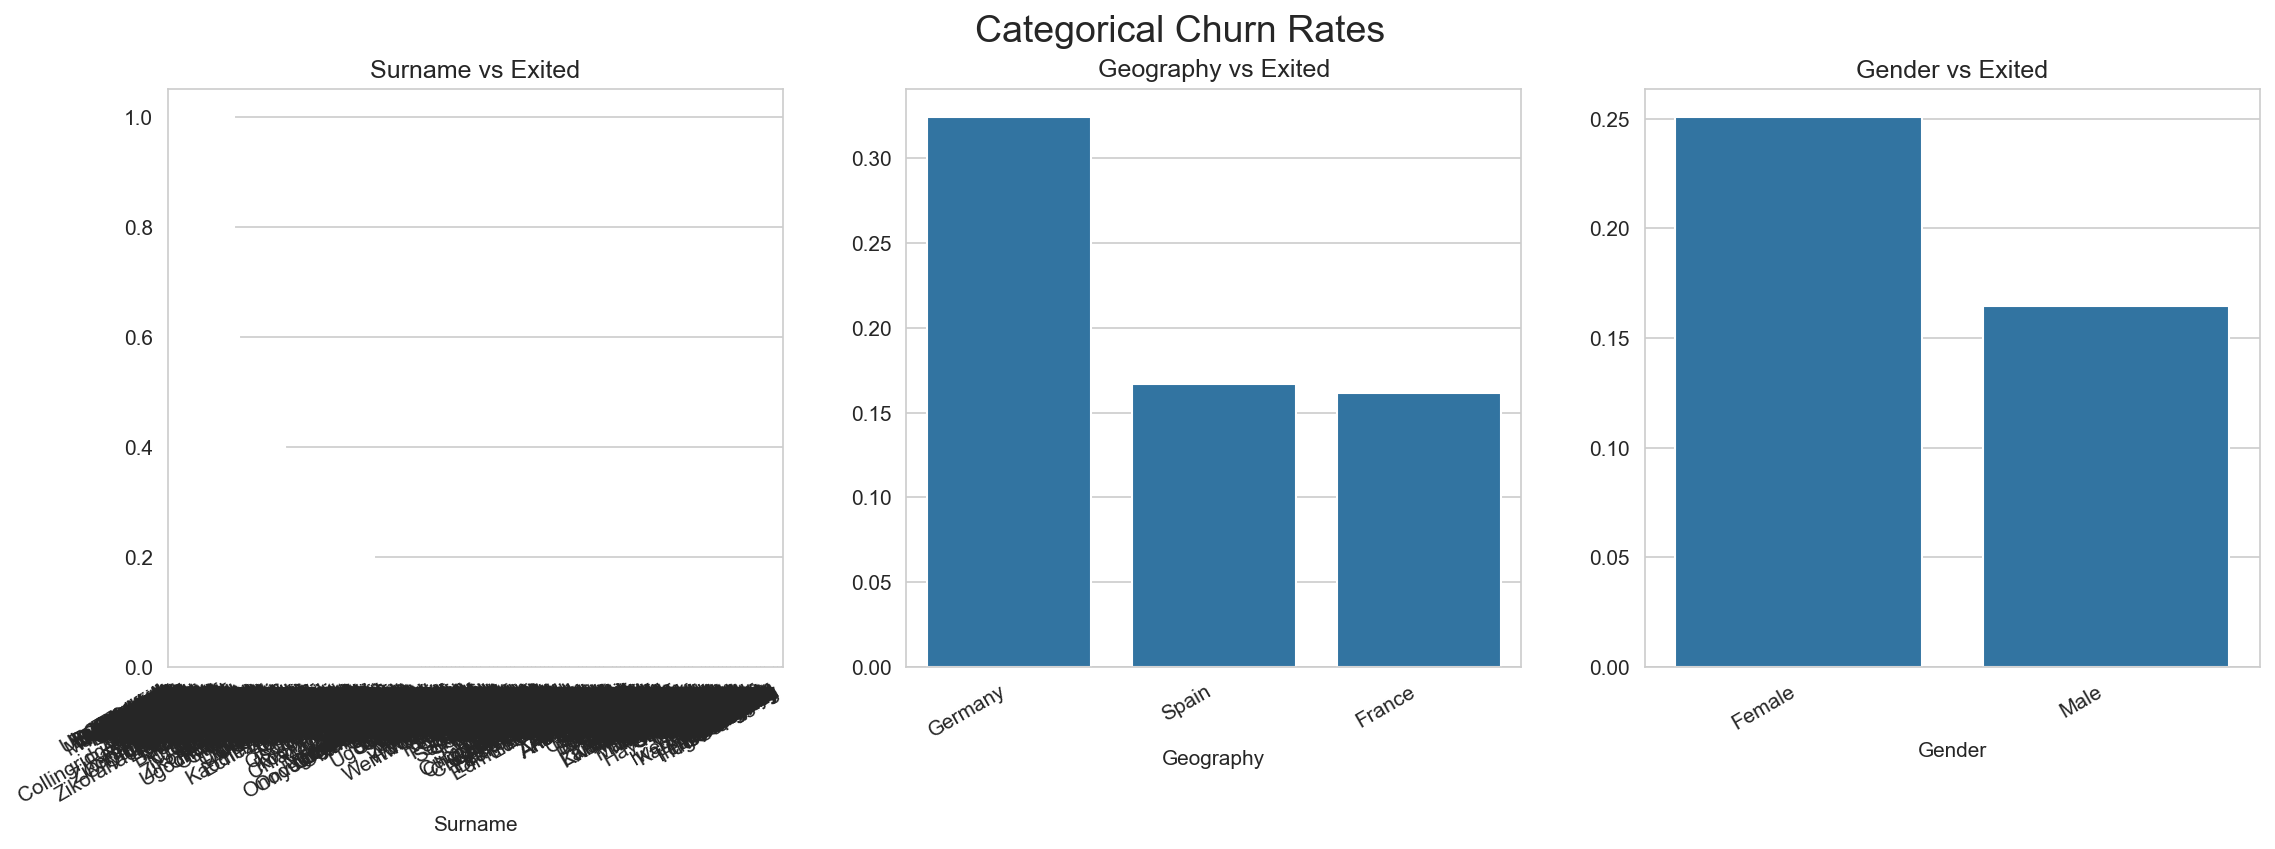

In [11]:
#=============================================
# 08. Categorical Churn Rates
#=============================================
if len(categorical_columns) > 0:
    plot_categorical_bars(data, categorical_columns, target_column=TARGET_COLUMN)
    #Inline Preview of the saved image
    display(Image(filename=os.path.join(REPORTS_EDA_DIRECTORY, "plot_categorical_bars.png")))
else:
    print("No categorical columns detected.")



Figure Saved: ../reports\eda\plot_correlation_heatmap.png


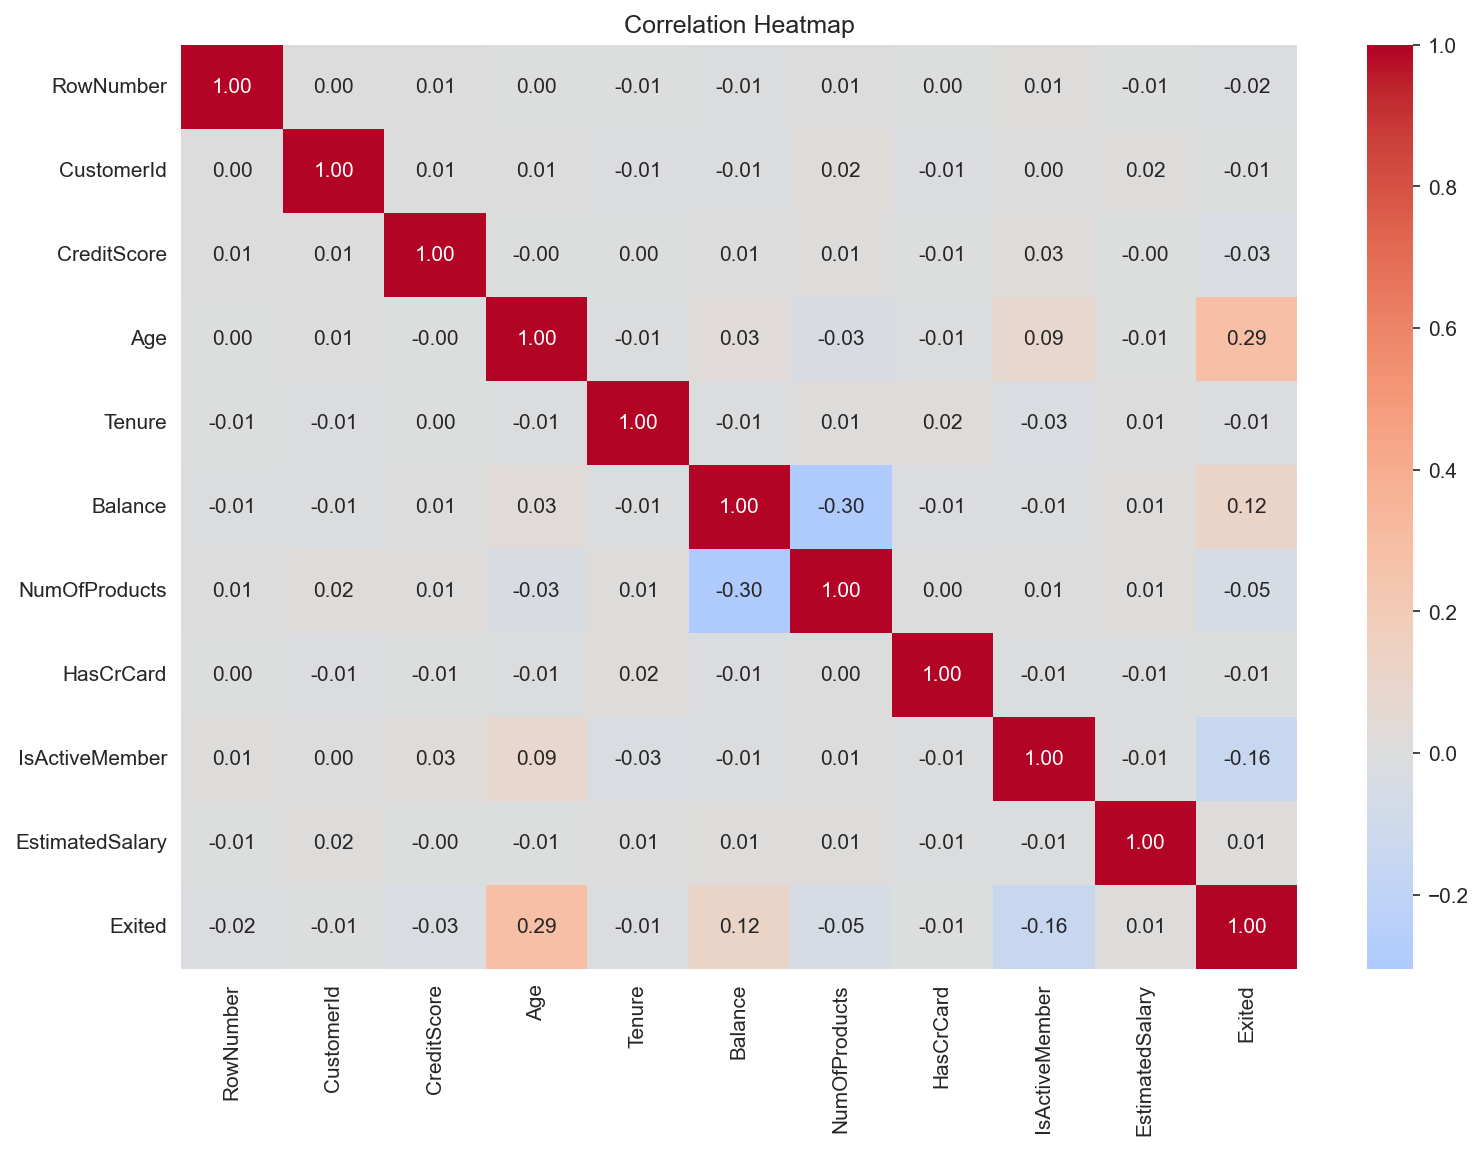

In [12]:
#=============================================
# 09. Correlation Heatmap
#=============================================
if len(numeric_columns) > 0:
    plot_correlation_heatmap(data, numeric_columns, target_column=TARGET_COLUMN)
    #Inline Preview of the saved image
    display(Image(filename=os.path.join(REPORTS_EDA_DIRECTORY, "plot_correlation_heatmap.png")))
else:
    print("No numeric columns detected.")


In [13]:
#=============================================
# 10. Export EDA  Summary(to generate insights through/downstream)
#=============================================
eda_summary = {"shape": {"rows": int(data.shape[0]),
                         "columns": int(data.shape[1])},
               "numeric_columns": numeric_columns,
               "categorical_columns": categorical_columns,
               "missing_percentage": {k: float(v) for k, v in data.isna().mean().to_dict().items()},
               "class_balance": {str(k): float(v) for k, v in data[TARGET_COLUMN].value_counts(normalize=True).to_dict().items()}
               }


save_json(eda_summary, os.path.join(REPORTS_EDA_DIRECTORY +"metadata/", "eda_summary.json"))

JSON Saved: ../reports/eda/metadata/eda_summary.json


In [14]:
#=============================================
# 11. Dataset Overview
#=============================================
dataset_overview = {"number_of_rows": data.shape[0],
                    "number_of_columns": data.shape[1],
                    "target_column": TARGET_COLUMN,
                    "numeric_columns": numeric_columns,
                    "categorical_columns": categorical_columns,
                    }

save_json(dataset_overview, os.path.join(REPORTS_EDA_DIRECTORY + "metadata/", "dataset_overview.json"))


JSON Saved: ../reports/eda/metadata/dataset_overview.json


In [15]:
#=============================================
# 12. Numeric Summary
#=============================================
numeric_summary = data[numeric_columns].describe().T.to_dict()
save_json(numeric_summary, os.path.join(REPORTS_EDA_DIRECTORY + "metadata/", "numeric_summary.json"))

JSON Saved: ../reports/eda/metadata/numeric_summary.json


In [16]:
#=============================================
# 13. Categorical Summary
#=============================================
categorical_summary = {}
for column in categorical_columns:
    value_counts = data[column].value_counts().head(5).to_dict()
    categorical_summary[column] = {"unique_values": data[column].nunique(),
                                   "top_5_values": value_counts}
save_json(categorical_summary, os.path.join(REPORTS_EDA_DIRECTORY + "metadata/", "categorical_summary.json"))

JSON Saved: ../reports/eda/metadata/categorical_summary.json


In [17]:
#=============================================
# 14. Missing Values
#=============================================
missing_values = data.isna().mean().sort_values(ascending=False).to_dict()
save_json(missing_values, os.path.join(REPORTS_EDA_DIRECTORY + "metadata/", "missing_values.json"))

JSON Saved: ../reports/eda/metadata/missing_values.json


In [18]:
#=============================================
# 15. Outlier Summary (IQR rule)
#=============================================
outlier_summary =  {}
for column in numeric_columns:
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    median = data[column].quantile(0.5)
    IQR = Q3 - Q1
    outliers = data[(data[column] < (Q1 - 1.5*IQR)) | (data[column] > (Q3 - 1.5*IQR))][column]
    outlier_summary[column] = {
        "iqr": IQR,
        "lower_bound": Q1 - 1.5*IQR,
        "median": median,
        "upper_bound": Q3 + 1.5*IQR,
        "outlier_count": outliers.count()
    }
save_json(json.loads(json.dumps(outlier_summary, default=str)), os.path.join(REPORTS_EDA_DIRECTORY + "metadata/", "outlier_summary.json"))    
    

JSON Saved: ../reports/eda/metadata/outlier_summary.json


## Next Steps

- Proceed to **Feature Engineering**:
  - Split Train/Validation **inside** `feature_engineering.py`
  - Build `ColumnTransformer` (scaler + one-hot)
  - Apply SMOTE on **train only**
  - Persist fitted transformers for reuse
  - Save processed `X_train`, `X_val`, `y_train`, `y_val`

> When you're ready, run:  
> `python src/feature_engineering.py`
